In [31]:
import os
import torch
import torchaudio
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import datasets
import tarfile
import re
import glob
import shutil

from sklearn.model_selection import train_test_split
from scipy.signal import welch
from tqdm.auto import tqdm

In [32]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Run Model on: {DEVICE}")

Run Model on: cuda


# Prepare Data for EDA

In [33]:
tarfile_path = r"dataset\urban-frdr\audio_2022_chunk_121.tar.gz"
csv_frdr = r"dataset\urban-frdr\inspections_2022.csv"
csv_zenodo = r"dataset\zenodo\state_labels.csv"
frdr_audiofolder_path = r"dataset/urban-frdr/audio_2022_all_chunk"
zenodo_audiofolder_path = r"dataset\zenodo"

### Extract chuck

In [34]:
# output_folder = "dataset/urban-frdr/audio_2022_chunk_121"
# with tarfile.open(tarfile_path,"r:gz") as tar:
#     tar.extractall(path=output_folder)

### checking status

In [35]:
df_frdr = pd.read_csv(csv_frdr)
target= df_frdr[(df_frdr['Queen status'] == 'queenless') | (df_frdr['Category'] == 'varroa')]
# print(target[['Date', 'Tag number', 'Category', 'Queen status']])

### check status on downloaded chuck

In [36]:
all_files = os.listdir(frdr_audiofolder_path)
extract_list = []
for file_path in all_files:
    if file_path.endswith('.wav'):
        file_name = file_path.split('/')[-1]
        parts = file_name.split('_')
        date = parts[0]
        hive_part = parts[2]
        hive_id = hive_part.split('-')[1].split('.')[0]
        for_merge = pd.to_datetime(date, format='%d-%m-%Y').strftime('%Y-%m-%d')
        extract_list.append({
            'Filename': file_name,
            'Date': for_merge,
            'Tag number': int(hive_id)
        })

df_audio = pd.DataFrame(extract_list)
df_audio['Tag number'] = df_audio['Tag number'].astype(int)

df_frdr['Tag number'] = df_frdr['Tag number'].astype(int)
df_frdr['Date'] = pd.to_datetime(df_frdr['Date']).dt.strftime('%Y-%m-%d')

# ทำไว้ใช้กันแถว infested ซ้ำกับ active
df_frdr_sorted = df_frdr.sort_values(by=['Date', 'Tag number', 'Category'], ascending=[True, True, False])
df_frdr_clean = df_frdr_sorted.drop_duplicates(subset=['Date', 'Tag number'], keep='first')
merge_df = pd.merge(df_audio, df_frdr_clean, on=['Date', 'Tag number'], how='inner')

def check_class(row):
    if row['Category'] == 'varroa':
        return 'Class 2: Infested'
    elif row['Queen status'] == 'queenless':
        return 'Class 1: Queenless'
    elif row['Queen status'] == 'queenright' and row['Is alive'] == 1:
        return 'Class 0: Active'
    else:
        return 'Others / Ignored'
merge_df['target_Class'] = merge_df.apply(check_class, axis=1)

# Check Other / Ignored (deaded bee)
# print(merge_df[merge_df['target_Class'] == 'Others / Ignored'])

for index, row in merge_df.iterrows():
    print(f"{index}. File: {row['Filename']} | {row['target_Class']}")
print(merge_df['target_Class'].value_counts())

0. File: 01-09-2022_00h30_HIVE-3631_Infested.wav | Class 2: Infested
1. File: 01-09-2022_02h00_HIVE-3631_Infested.wav | Class 2: Infested
2. File: 01-09-2022_02h45_HIVE-3631_Infested.wav | Class 2: Infested
3. File: 01-09-2022_06h30_HIVE-6_Infested.wav | Class 2: Infested
4. File: 01-09-2022_07h15_HIVE-3631_Infested.wav | Class 2: Infested
5. File: 01-09-2022_07h30_HIVE-6_Infested.wav | Class 2: Infested
6. File: 01-09-2022_07h45_HIVE-3631_Infested.wav | Class 2: Infested
7. File: 01-09-2022_12h30_HIVE-6_Infested.wav | Class 2: Infested
8. File: 01-09-2022_13h00_HIVE-3693_Active.wav | Class 0: Active
9. File: 01-09-2022_13h00_HIVE-6_Infested.wav | Class 2: Infested
10. File: 01-09-2022_13h15_HIVE-3631_Infested.wav | Class 2: Infested
11. File: 01-09-2022_13h15_HIVE-3690_Active.wav | Class 0: Active
12. File: 01-09-2022_14h30_HIVE-3693_Active.wav | Class 0: Active
13. File: 01-09-2022_16h45_HIVE-3631_Infested.wav | Class 2: Infested
14. File: 01-09-2022_16h45_HIVE-3691_Active.wav | Clas

In [37]:
# unmapped_folder_path = os.path.join(os.path.dirname(frdr_audiofolder_path), "unmapped_audio")
# if not os.path.exists(unmapped_folder_path):
#     os.makedirs(unmapped_folder_path)
# frdr_class_map = {}
# for index, row in merge_df.iterrows():
#     old_name = row['Filename']
#     current_class = row['target_Class']
#     class_suffix = current_class.split(': ')[1] # ดึงคำ Active, Queenless, Infested ออกมา
#     frdr_class_map[old_name] = class_suffix

# all_files_in_folder = os.listdir(frdr_audiofolder_path)

# rename_count = 0
# move_count = 0
# for filename in tqdm(all_files_in_folder, total=len(all_files_in_folder)):
    
#     if filename.endswith('.wav'):
#         old_file_path = os.path.join(frdr_audiofolder_path, filename)
        
#         if filename in frdr_class_map:
#             class_suffix = frdr_class_map[filename]
            
#             name_part, ext_part = os.path.splitext(filename)
#             new_filename = f"{name_part}_{class_suffix}{ext_part}"
#             new_file_path = os.path.join(frdr_audiofolder_path, new_filename)
            
#             if os.path.exists(old_file_path):
#                 os.rename(old_file_path, new_file_path)
#                 rename_count += 1
                
#         else:
#             destination_file_path = os.path.join(unmapped_folder_path, filename)
            
#             if os.path.exists(old_file_path):
#                 shutil.move(old_file_path, destination_file_path) # สั่งย้ายไฟล์ข้ามโฟลเดอร์
#                 move_count += 1

# print(f"Found: {rename_count} Files")

# Exploratory Data Analysis (EDA)

### Compare noise level (Active)

C:\Users\USER\AppData\Local\Temp\ipykernel_19672\2378925140.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_durations, x='Dataset', y='Duration', ax=ax_duration, palette='Pastel1', width=0.3)


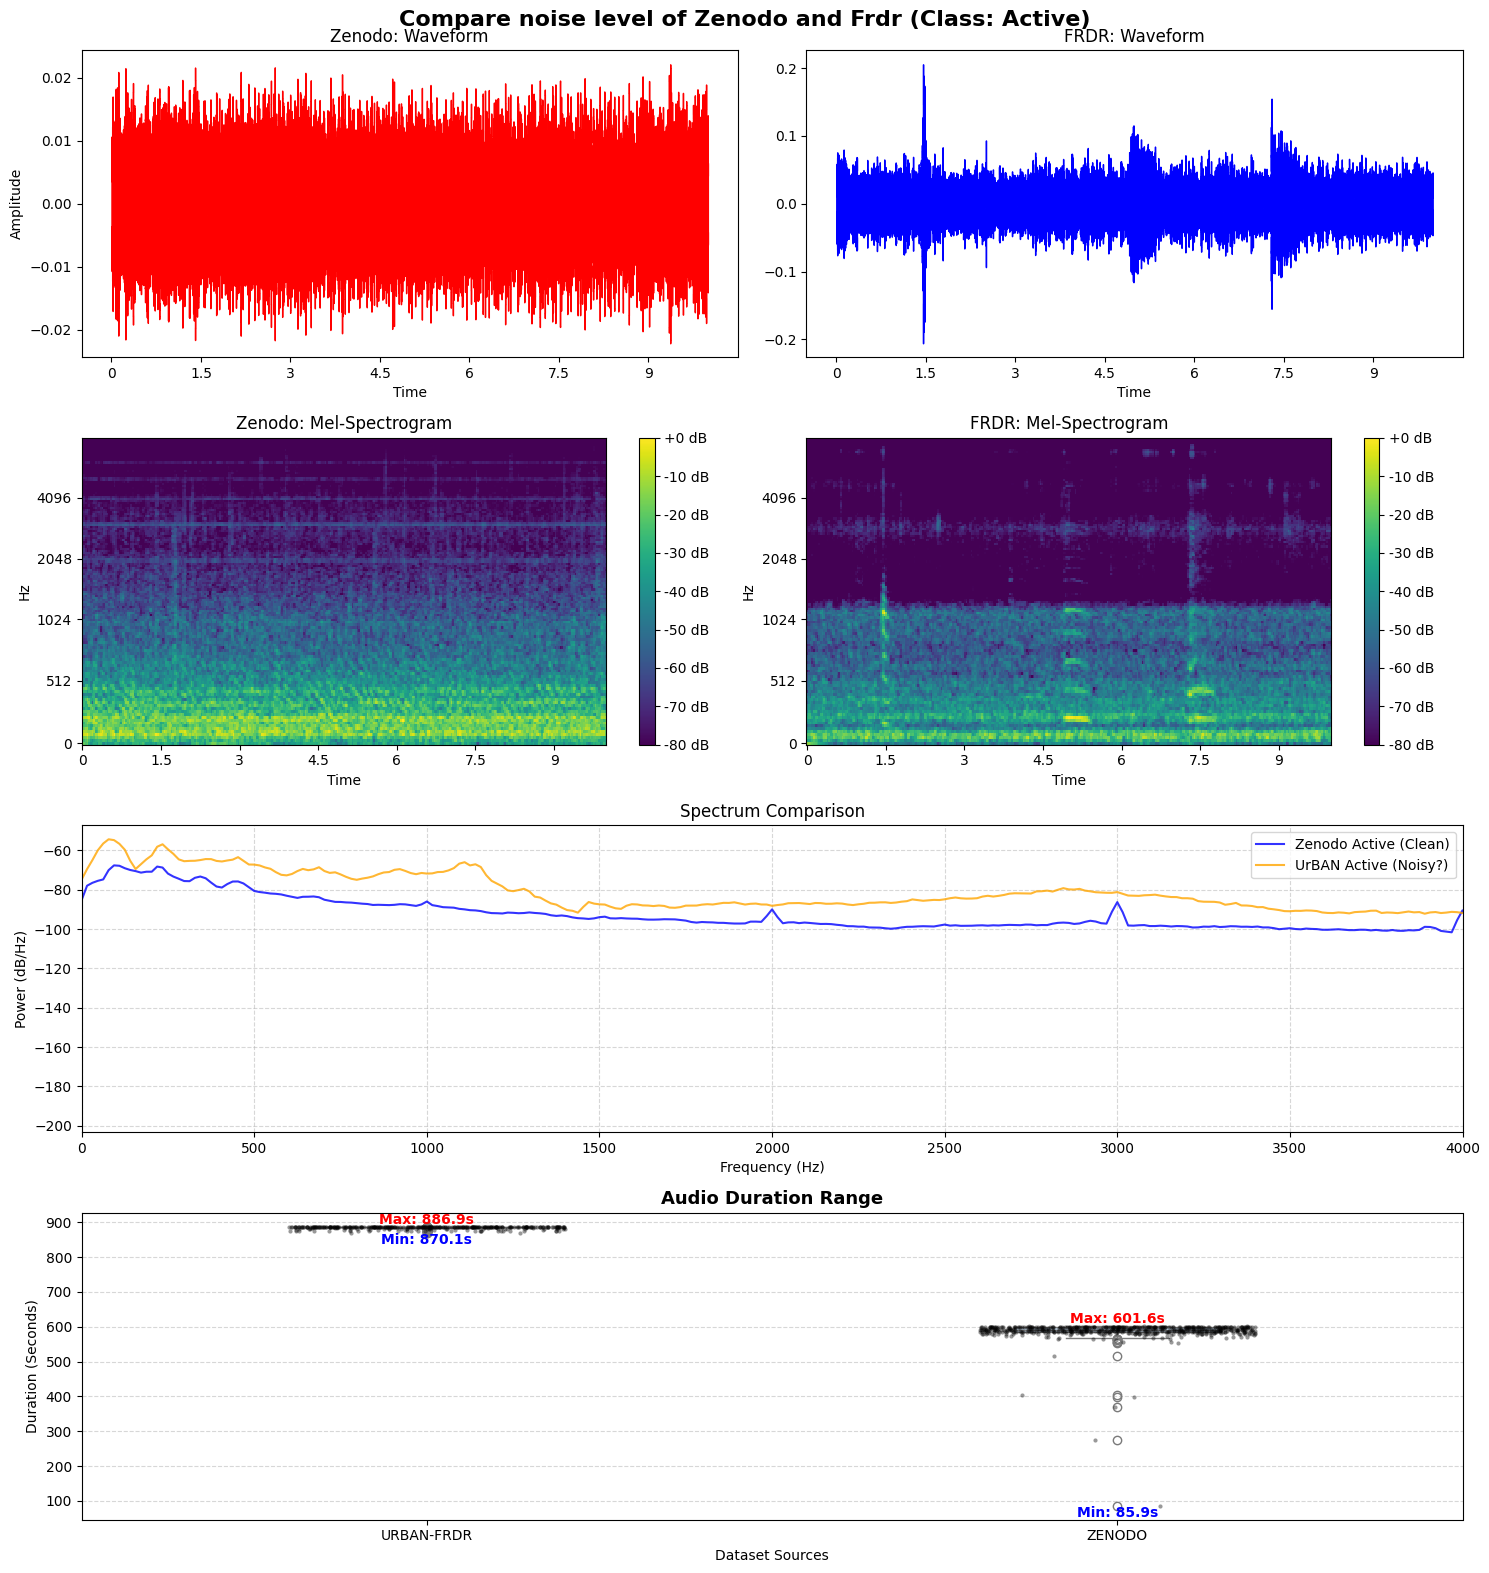

In [47]:
zenodo_active_path = r"dataset\zenodo\Hive1_12_06_2018\Hive1 12_06_2018_QueenBee____00_00_00.wav"
frdr_active_path = r"dataset\urban-frdr\audio_2022_all_chunk\01-09-2022_20h30_HIVE-3693_Active.wav"

sample_rate = 16000
audio_zenodo, sr_z = librosa.load(zenodo_active_path, sr=sample_rate)
audio_frdr, sr_f = librosa.load(frdr_active_path, sr=sample_rate)

duration = 10 #(Sec)
audio_zenodo = audio_zenodo[:sample_rate * duration]
audio_frdr = audio_frdr[:sample_rate * duration]
# print(audio_frdr)

all_audio_files = glob.glob(r"dataset\**\*.wav", recursive=True)

all_duration_data = []

for path in all_audio_files:
    filename = os.path.basename(path)
    dataset_name = None
    
    filename_lower = filename.lower()
    if any(s in filename_lower for s in ["_active", "_queenless", "_infested"]):
        dataset_name = 'URBAN-FRDR'
    elif any(s in filename_lower for s in ["queenbee", "no_queenbee"]):
        dataset_name = 'ZENODO'
        
    if dataset_name:
        try:
            file_duration = librosa.get_duration(path=path)
            
            all_duration_data.append({
                'Dataset': dataset_name,
                'Duration': file_duration
            })
        except Exception as e:
            print(f"Error reading {filename}: {e}")

df_durations = pd.DataFrame(all_duration_data)

main_plot, sub_plot = plt.subplots(4, 2, figsize=(15, 16), sharex=False)
main_plot.suptitle("Compare noise level of Zenodo and Frdr (Class: Active)", fontsize=16, fontweight='bold')
sub_plot[0, 0].set_title("Zenodo: Waveform")
librosa.display.waveshow(audio_zenodo, sr=sample_rate, ax=sub_plot[0, 0], color='red')
sub_plot[0, 0].set_ylabel("Amplitude")

sub_plot[0, 1].set_title("FRDR: Waveform")
librosa.display.waveshow(audio_frdr, sr=sample_rate, ax=sub_plot[0, 1], color='blue')
#=============================================================
mel_zenodo = librosa.feature.melspectrogram(y=audio_zenodo, sr=sample_rate, n_mels=128)
mel_db_zenodo = librosa.amplitude_to_db(mel_zenodo, ref=np.max)

sub_plot[1, 0].set_title("Zenodo: Mel-Spectrogram")
img1 = librosa.display.specshow(mel_db_zenodo, sr=sample_rate, x_axis='time', y_axis='mel', ax=sub_plot[1, 0], cmap='viridis')
main_plot.colorbar(img1, ax=sub_plot[1,0], format='%+2.0f dB')

mel_frdr = librosa.feature.melspectrogram(y=audio_frdr, sr=sample_rate, n_mels=128)
mel_db_frdr = librosa.amplitude_to_db(mel_frdr, ref=np.max)
sub_plot[1, 1].set_title("FRDR: Mel-Spectrogram")
img2 = librosa.display.specshow(mel_db_frdr, sr=sample_rate, x_axis='time', y_axis='mel', ax=sub_plot[1, 1], cmap='viridis')
main_plot.colorbar(img2, ax=sub_plot[1,1], format='%+2.0f dB')
#=============================================================

freqs_z, psd_z = welch(audio_zenodo, sample_rate, nperseg=1024)
freqs_u, psd_u = welch(audio_frdr, sample_rate, nperseg=1024)

sub_plot[2, 0].remove()
sub_plot[2, 1].remove()
ax_psd = main_plot.add_subplot(4, 1, 3)

ax_psd.plot(freqs_z, 10 * np.log10(psd_z), label='Zenodo Active (Clean)', color='blue', alpha=0.8)
ax_psd.plot(freqs_u, 10 * np.log10(psd_u), label='UrBAN Active (Noisy?)', color='orange', alpha=0.8)
ax_psd.set_title("Spectrum Comparison")
ax_psd.set_xlabel("Frequency (Hz)")
ax_psd.set_ylabel("Power (dB/Hz)")
ax_psd.set_xlim(0, 4000)
ax_psd.grid(True, linestyle='--', alpha=0.5)
ax_psd.legend()
#=============================================================

sub_plot[3, 0].remove()
sub_plot[3, 1].remove()
ax_duration = main_plot.add_subplot(4, 1, 4)

if len(df_durations) > 0:
    sns.boxplot(data=df_durations, x='Dataset', y='Duration', ax=ax_duration, palette='Pastel1', width=0.3)
    sns.stripplot(data=df_durations, x='Dataset', y='Duration', ax=ax_duration, color='black', size=3, alpha=0.4, jitter=0.2)
    
    for i, dataset_name in enumerate(['URBAN-FRDR', 'ZENODO']):
        sub_df = df_durations[df_durations['Dataset'] == dataset_name]['Duration']
        if len(sub_df) > 0:
            ax_duration.text(i, sub_df.max(), f"Max: {sub_df.max():.1f}s", ha='center', va='bottom', color='red', fontweight='bold', fontsize=10)
            ax_duration.text(i, sub_df.min(), f"Min: {sub_df.min():.1f}s", ha='center', va='top', color='blue', fontweight='bold', fontsize=10)

ax_duration.set_title("Audio Duration Range", fontsize=13, fontweight='bold')
ax_duration.set_xlabel("Dataset Sources")
ax_duration.set_ylabel("Duration (Seconds)")
ax_duration.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [50]:
too_short = df_durations[
    (df_durations['Dataset'] == 'ZENODO') & 
    (df_durations['Duration'] < 500)
]

if len(too_short) > 0:
    print(f"Too short found: {len(too_short)} File\n")
    for idx, row in too_short.iterrows():
        target_duration = row['Duration']
        for path in all_audio_files:
            if "queenbee" in path.lower() or "no_queenbee" in path.lower():
                try:
                    import librosa
                    d = librosa.get_duration(path=path)
                    if abs(d - target_duration) < 0.1:
                        found_filename = os.path.basename(path)
                        break
                except:
                    pass
        
        print(f"File name: {found_filename}")
        print(f"Duration: {target_duration:.2f} Sec (About {target_duration/60:.1f} Min)")
else:
    print("Not found")

Too short found: 5 File

File name: Hive3_14_07_2017_NO_QueenBee____07_30_00.wav
Duration: 274.00 Sec (About 4.6 Min)
File name: Hive3_14_07_2017_NO_QueenBee____09_30_00.wav
Duration: 397.06 Sec (About 6.6 Min)
File name: Hive3_28_07_2017_QueenBee____07_40_00.wav
Duration: 369.20 Sec (About 6.2 Min)
File name: Hive3_28_07_2017_QueenBee____11_30_00.wav
Duration: 402.52 Sec (About 6.7 Min)
File name: Hive3_28_07_2017_QueenBee____12_40_00.wav
Duration: 85.91 Sec (About 1.4 Min)


In [39]:
frdr_hives = df_audio['Tag number'].unique()
total_frdr_hives = len(frdr_hives)

print(f"Total FRDR Hive: {total_frdr_hives} hives")
print(f"FRDR Name list: {sorted(frdr_hives)}")

Total FRDR Hive: 9 hives
FRDR Name list: [np.int64(6), np.int64(3627), np.int64(3628), np.int64(3631), np.int64(3640), np.int64(3690), np.int64(3691), np.int64(3692), np.int64(3693)]


## Data split

In [40]:
frdr_files = glob.glob(os.path.join(frdr_audiofolder_path, "*.wav"))
frdr_data = []

for path in frdr_files:
    filename = os.path.basename(path)
    # คัดให้เหลือแค่ไฟล์ที่เปลี่ยนชื่อแล้ว
    if any(suffix in filename for suffix in ["_Active", "_Queenless", "_Infested"]):
        name_part, _ = os.path.splitext(filename)
        parts = name_part.split('_')
        class_label = parts[-1] 
        hive_id = [p for p in parts if "HIVE" in p][0] if any("HIVE" in p for p in parts) else "Unknown"
        
        frdr_data.append({
            'File_Path': path,
            'Filename': filename,
            'Dataset': 'FRDR',
            'Class': class_label,
            'Hive': hive_id
        })

df_frdr_all = pd.DataFrame(frdr_data)
# ----------------------------------------------------- zenodo
zenodo_files = glob.glob(os.path.join(zenodo_audiofolder_path, "*", "*.wav"))
zenodo_data = []

for path in zenodo_files:
    filename = os.path.basename(path)
    folder_name = os.path.basename(os.path.dirname(path)) # ดึงชื่อโฟลเดอร์หลักมา เช่น Hive1_12_06_2018

    if "NO_QueenBee" in filename:
        class_label = "Queenless"
    elif "QueenBee" in filename:
        class_label = "Active"
    else:
        continue
        
    hive_id = folder_name.split('_')[0]
    
    zenodo_data.append({
        'File_Path': path,
        'Filename': filename,
        'Dataset': folder_name,
        'Class': class_label,
        'Hive': hive_id
    })

df_zenodo_all = pd.DataFrame(zenodo_data)

print(f"UrBAN-FRDR: {len(df_frdr_all)} Files")
print(f"Zenodo: {len(df_zenodo_all)} Files")

def split_data(df, stratify_col):
    if len(df) < 10:
        train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42)
        val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)
        return train_df, val_df, test_df
    train_df, temp_df = train_test_split(
        df, 
        test_size=0.20, 
        random_state=42, 
        stratify=df[stratify_col] if stratify_col in df.columns else None
    )
    
    val_df, test_df = train_test_split(
        temp_df, 
        test_size=0.50, 
        random_state=42, 
        stratify=temp_df[stratify_col] if stratify_col in temp_df.columns else None
    )
    
    return train_df, val_df, test_df

zenodo_train_list, zenodo_val_list, zenodo_test_list = [], [], []

for folder, group in df_zenodo_all.groupby('Dataset'):
    z_train, z_val, z_test = split_data(group, stratify_col='Class')
    zenodo_train_list.append(z_train)
    zenodo_val_list.append(z_val)
    zenodo_test_list.append(z_test)

train_zenodo = pd.concat(zenodo_train_list)
val_zenodo = pd.concat(zenodo_val_list)
test_zenodo = pd.concat(zenodo_test_list)
df_frdr_all['Stratify_Key'] = df_frdr_all['Class'] + "_" + df_frdr_all['Hive']

counts = df_frdr_all['Stratify_Key'].value_counts()
rare_keys = counts[counts < 10].index
df_frdr_all['Stratify_Key'] = df_frdr_all['Stratify_Key'].apply(lambda x: x.split('_')[0] if x in rare_keys else x)

train_frdr, val_frdr, test_frdr = split_data(df_frdr_all, stratify_col='Stratify_Key')


train_df = pd.concat([train_zenodo, train_frdr], ignore_index=True).drop(columns=['Stratify_Key'], errors='ignore')
val_df = pd.concat([val_zenodo, val_frdr], ignore_index=True).drop(columns=['Stratify_Key'], errors='ignore')
test_df = pd.concat([test_zenodo, test_frdr], ignore_index=True).drop(columns=['Stratify_Key'], errors='ignore')

print(f"Total files: Train = {len(train_df)} | Val = {len(val_df)} | Test = {len(test_df)}")
print("\n")

print("1. Split by Dataset:")
summary_dataset = pd.DataFrame({
    'Train_Set': train_df['Dataset'].value_counts(),
    'Val_Set': val_df['Dataset'].value_counts(),
    'Test_Set': test_df['Dataset'].value_counts()
}).fillna(0).astype(int)
summary_dataset['Total'] = summary_dataset.sum(axis=1)
print(summary_dataset)
print("\n")

print("2. Split by Class:")
summary_class = pd.DataFrame({
    'Train_Set': train_df['Class'].value_counts(),
    'Val_Set': val_df['Class'].value_counts(),
    'Test_Set': test_df['Class'].value_counts()
}).fillna(0).astype(int)
summary_class['Total'] = summary_class.sum(axis=1)
print(summary_class)
print("\n")

print("3. Split by Hive:")
summary_hive = pd.DataFrame({
    'Train_Set': train_df['Hive'].value_counts(),
    'Val_Set': val_df['Hive'].value_counts(),
    'Test_Set': test_df['Hive'].value_counts()
}).fillna(0).astype(int)
summary_hive['Total'] = summary_hive.sum(axis=1)
print(summary_hive)

UrBAN-FRDR: 204 Files
Zenodo: 576 Files
Total files: Train = 623 | Val = 76 | Test = 81


1. Split by Dataset:
                  Train_Set  Val_Set  Test_Set  Total
Dataset                                              
FRDR                    163       20        21    204
Hive1_12_06_2018        115       14        15    144
Hive1_31_05_2018        115       14        15    144
Hive3_14_07_2017        115       14        15    144
Hive3_28_07_2017        115       14        15    144


2. Split by Class:
           Train_Set  Val_Set  Test_Set  Total
Class                                         
Active           306       37        41    384
Queenless        260       32        33    325
Infested          57        7         7     71


3. Split by Hive:
           Train_Set  Val_Set  Test_Set  Total
Hive                                          
HIVE-3627          0        0         1      1
HIVE-3628         12        2         2     16
HIVE-3631         31        3         5     39
